In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [3]:
gender_submission_data = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')
test_data = pd.read_csv('/kaggle/input/titanic/test.csv')
train_data = pd.read_csv('/kaggle/input/titanic/train.csv')

In [4]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. How many rows and columns are there?

In [5]:
train_data.shape

(891, 12)

2. What are the data types of each column?

In [6]:
train_data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

3.Which columns are numerical and which are which are categorical?

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


4.How many passengers survived? What percentage survived?

In [8]:
survived = train_data.Survived.value_counts()
survived_percentage = (survived/train_data.Survived.shape)*100
survived_percentage

Survived
0    61.616162
1    38.383838
Name: count, dtype: float64

5.How many male vs female passengers?

In [9]:
train_data.Sex.value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

6. What is the average age?

In [10]:
train_data.Age.mean()

np.float64(29.69911764705882)

7. What is the median fare?

In [11]:
train_data.Fare.median()

14.4542

8. What is the maximum fare paid?

In [12]:
train_data.Fare.max()

512.3292

9. How many unique passenger classes (Pclass) are there?

In [13]:
train_data.Pclass.unique()

array([3, 1, 2])

10. What percentage of passengers traveled in each class?

In [14]:
(train_data.Pclass.value_counts()/len(train_data.Pclass))*100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64

In [15]:
(train_data.Pclass.value_counts(normalize=True))*100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

11. Which columns contain missing values?

In [16]:
train_data.isnull().sum()>0

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked        True
dtype: bool

12. How many missing values in each column?

In [17]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

13. What percentage of Age is missing?

In [18]:
(train_data.Age.isnull().sum()/train_data.Age.size)*100

np.float64(19.865319865319865)

14. What percentage of Cabin is missing?

In [19]:
(train_data.Cabin.isnull().sum()/len(train_data.Cabin))*100

np.float64(77.10437710437711)

15. What happens if you drop all rows with missing values?

In [20]:
print(f"Before droping the size of the dataset was {train_data.shape}")
print(f"After droping all rows with missing columns size of dataset  is {train_data.dropna().shape}")

Before droping the size of the dataset was (891, 12)
After droping all rows with missing columns size of dataset  is (183, 12)


16. Fill Age with:

Mean and 
Median

Compare difference.

In [21]:
train_data['Age_mean'] = train_data['Age'].fillna(train_data.Age.mean())
train_data['Age_median'] = train_data['Age'].fillna(train_data.Age.median())
print(f"Age filled with mean is {train_data.Age_mean}")
print(f"Age filled with median is {train_data.Age_median}")

Age filled with mean is 0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age_mean, Length: 891, dtype: float64
Age filled with median is 0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age_median, Length: 891, dtype: float64


17. Fill Embarked with most frequent value.

In [22]:
Frequent_value = train_data['Embarked'].value_counts().idxmax()
train_data['Embarked'] = train_data['Embarked'].fillna(Frequent_value)
train_data['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [23]:
train_data['Embarked'].fillna(train_data.Embarked.mode().max(),inplace=True)

18. Create a new column Age_is_missing (1 if missing, 0 if not).

In [24]:
train_data['Age_is_missing'] = train_data.Age.isnull().astype(int)
train_data.Age_is_missing

0      0
1      0
2      0
3      0
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: Age_is_missing, Length: 891, dtype: int64

19. What is survival rate of males?

In [25]:
(train_data[train_data['Sex']=='male']['Survived'].mean())*100


np.float64(18.890814558058924)

20. What is survival rate of females?

In [26]:
(train_data[train_data['Sex']=='female']['Survived'].mean())*100

np.float64(74.20382165605095)

21. Survival rate by Pclass?

In [27]:
train_data.groupby('Pclass')['Survived'].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

22. Survival rate of females in 1st class?

In [28]:
train_data.Survived[(train_data['Pclass'] == 1) & (train_data['Sex'] == 'female')].mean()*100



np.float64(96.80851063829788)

23. Average age of survivors vs non-survivors?

In [29]:
train_data.groupby('Survived')['Age'].mean()*100

Survived
0    3062.617925
1    2834.368966
Name: Age, dtype: float64

Or......

In [30]:
survived = ((train_data['Survived'] == 1) & (train_data['Age'])).mean()*100
non_survived = ((train_data['Survived'] == 0) & (train_data['Age'])).mean()*100
print(f"Average age of survivors is {survived}")
print(f"Average age of non-suvivors is {non_survived}")

Average age of survivors is 32.547699214365885
Average age of non-suvivors is 47.586980920314254


24. Average fare paid by each class?

In [31]:
train_data.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

25. Which class paid highest fare on average?

In [32]:
high_class = train_data.groupby('Pclass')['Fare'].mean().idxmax()
high_fare = train_data.groupby('Pclass')['Fare'].mean().max()
print(f"Highest fare was paid by class {high_class} and of amount of  {high_fare}")

Highest fare was paid by class 1 and of amount of  84.1546875


26. Count passengers by Embarked location.

In [33]:
train_data.Embarked.value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

27. Which embarkation port had highest survival rate?

In [34]:
embarkation_survival = train_data.groupby('Embarked')['Survived'].mean()*100
print(f"The embarkation port with highest survival rate is {embarkation_survival.max()} ")

The embarkation port with highest survival rate is 55.35714285714286 


28. Plot histogram of Age.

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

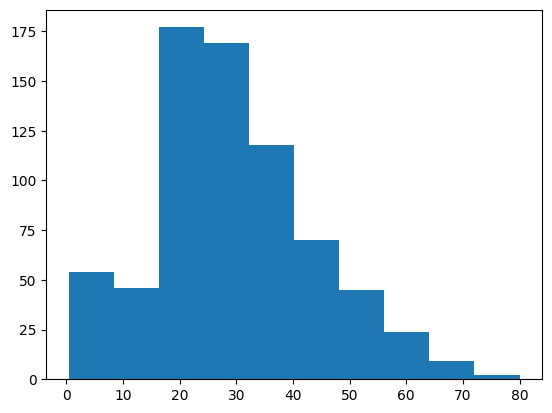

In [35]:
plt.hist(train_data.Age)

29. Plot histogram of Fare.

(array([732., 106.,  31.,   2.,  11.,   6.,   0.,   0.,   0.,   3.]),
 array([  0.     ,  51.23292, 102.46584, 153.69876, 204.93168, 256.1646 ,
        307.39752, 358.63044, 409.86336, 461.09628, 512.3292 ]),
 <BarContainer object of 10 artists>)

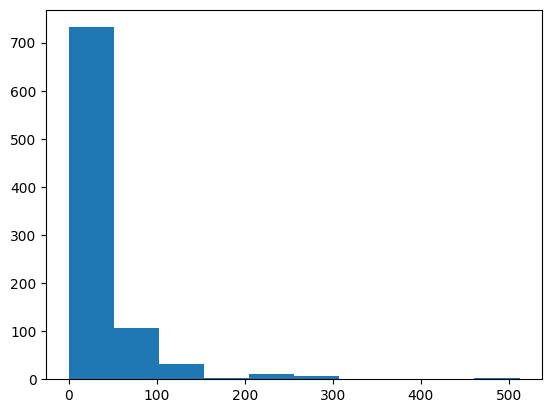

In [36]:
plt.hist(train_data.Fare)


30. Bar chart of survival count.

<Axes: xlabel='Survived'>

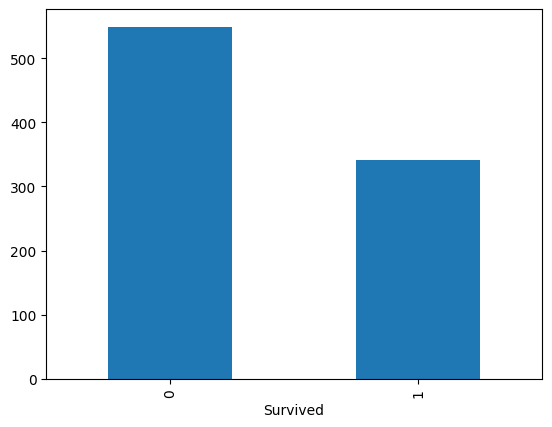

In [37]:
train_data['Survived'].value_counts().plot(kind='bar')

31. Bar chart of survival by gender.

<Axes: xlabel='Sex'>

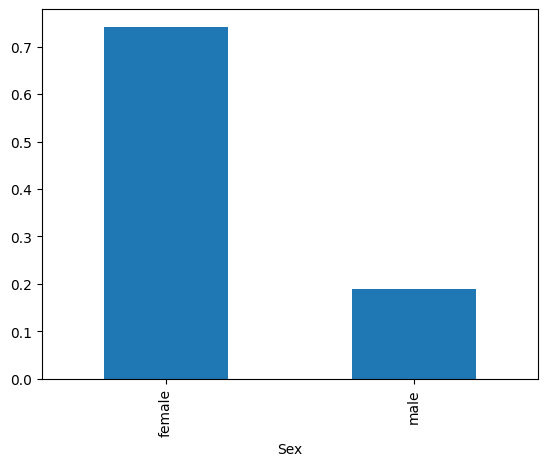

In [38]:
train_data.groupby('Sex')['Survived'].mean().plot(kind='bar')

32. Bar chart of survival by class.

<Axes: xlabel='Pclass'>

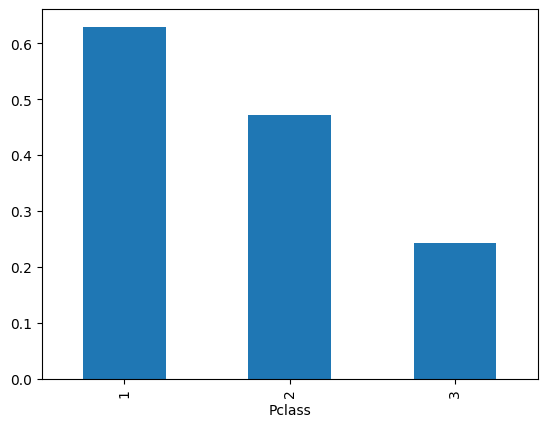

In [39]:
train_data.groupby('Pclass')['Survived'].mean().plot(kind='bar')

33. Boxplot of Fare grouped by class.

<Axes: title={'center': 'Fare'}, xlabel='Pclass'>

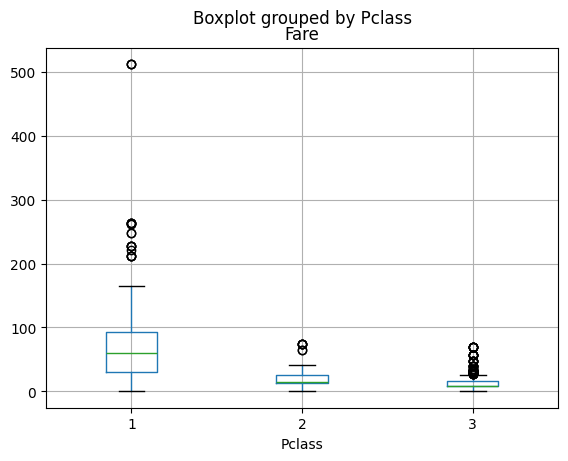

In [40]:
train_data.boxplot(column='Fare',by='Pclass')

34. Scatter plot of Age vs Fare.

<Axes: xlabel='Age', ylabel='Fare'>

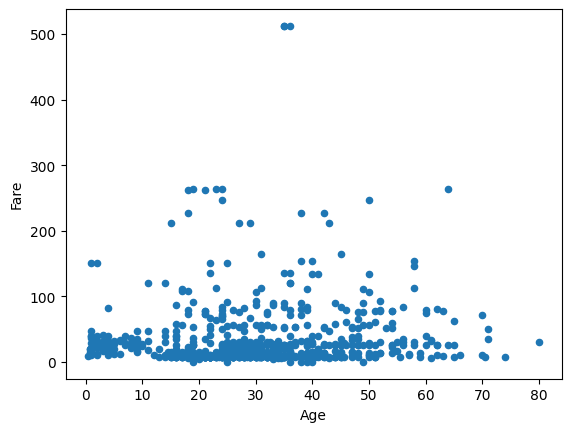

In [41]:
train_data.plot.scatter(x='Age',y='Fare')

35. Pie chart of class distribution.

<Axes: ylabel='count'>

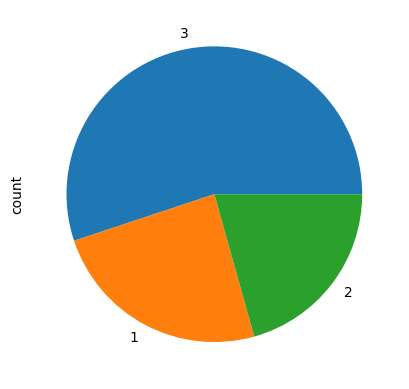

In [42]:
train_data['Pclass'].value_counts().plot(kind='pie')

37. Create a column FamilySize = SibSp + Parch + 1

In [43]:
train_data['FamilySize']=train_data['SibSp']+train_data['Parch']+1
train_data.FamilySize

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: FamilySize, Length: 891, dtype: int64

38. Which family size has highest survival rate?

In [44]:
family_survival_rate = train_data.groupby('FamilySize')['Survived'].mean()*100
print(f"The family size with highest survival rate is {family_survival_rate.max()}")

The family size with highest survival rate is 72.41379310344827


39. Create a binary column: IsAlone

In [45]:
train_data['IsAlone']=(train_data['FamilySize'] == 1).astype(int)
train_data.IsAlone

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: IsAlone, Length: 891, dtype: int64

40. Compare survival rate of alone vs non-alone passengers.

In [46]:
train_data.groupby('IsAlone')['Survived'].mean()*100

IsAlone
0    50.564972
1    30.353818
Name: Survived, dtype: float64

41. Extract title from Name (Mr, Mrs, Miss, etc.)

In [47]:
train_data['Title'] = train_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [48]:
#replacing rare titles with rare word
train_data['Title'] = train_data['Title'].replace(
    ['Lady','Countess','Capt','Col',
     'Don','Dr','Major','Rev','Sir',
     'Jonkheer','Dona'],
    'Rare'
)

In [49]:
train_data['Title'] = train_data['Title'].replace(
    ['Mlle','Ms'],
    'Miss'
)

train_data['Title'] = train_data['Title'].replace(
    'Mme',
    'Mrs'
)
train_data['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [50]:
train_data['Age'] = train_data['Age'].fillna(
    train_data['Age'].median()
)

In [51]:
#removing unnecessary columns
train_data = train_data.drop(
    columns=[
        'PassengerId',
        'Name',
        'Ticket',
        'Cabin'
    ]
)

In [52]:
le = LabelEncoder()

train_data['Sex'] = le.fit_transform(
    train_data['Sex']
)

train_data['Embarked'] = le.fit_transform(
    train_data['Embarked']
)

train_data['Title'] = le.fit_transform(
    train_data['Title']
)

In [53]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_mean,Age_median,Age_is_missing,FamilySize,IsAlone,Title
0,0,3,1,22.0,1,0,7.2500,2,22.0,22.0,0,2,0,2
1,1,1,0,38.0,1,0,71.2833,0,38.0,38.0,0,2,0,3
2,1,3,0,26.0,0,0,7.9250,2,26.0,26.0,0,1,1,1
3,1,1,0,35.0,1,0,53.1000,2,35.0,35.0,0,2,0,3
4,0,3,1,35.0,0,0,8.0500,2,35.0,35.0,0,1,1,2


In [54]:
X = train_data.drop(
    columns=['Survived']
)

y = train_data['Survived']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 13)
(179, 13)


In [56]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

lr_predictions = lr_model.predict(
    X_test
)

In [57]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:")
print(lr_accuracy)

Logistic Regression Accuracy:
0.8100558659217877


In [58]:
cm = confusion_matrix(y_test, lr_predictions)


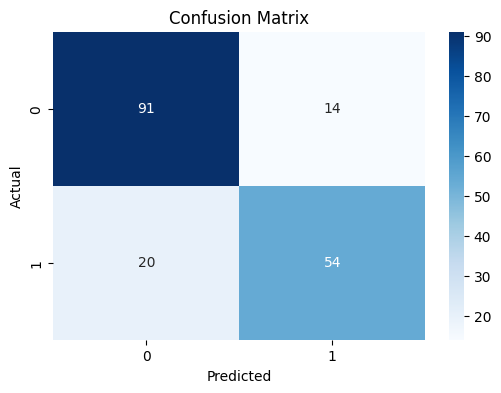

In [59]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [60]:
print(classification_report(y_test,lr_predictions))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

